# Time-Resolved Decoder Projections: GO vs STOP Trials

This notebook analyzes how neural activity projects onto the FIX-GO decoder axis over time.

**Key Analyses:**
1. Single exemplar trials (GO vs STOP)
2. Population average across all trials
3. Bootstrap analysis (1000 iterations)

**Session**: fi211025a (63 neurons)  
**SSD level**: 2 (~108ms)

---

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import joblib
import torch
import torch.nn as nn

# Set style
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Imports loaded successfully!")

Imports loaded successfully!


## Define Xie Decoder Architecture

In [2]:
class XieDecoder(nn.Module):
    """Xie-style decoder with 2D hidden layer."""
    def __init__(self, n_neurons, hidden_dim=2, n_classes=2):
        super().__init__()
        self.n_neurons = n_neurons
        self.hidden_dim = hidden_dim
        self.n_classes = n_classes
        
        self.W = nn.Linear(n_neurons, hidden_dim, bias=True)
        self.M = nn.Linear(hidden_dim, n_classes, bias=False)
    
    def forward(self, x):
        h = self.W(x)
        logits = self.M(h)
        return logits, h
    
    def predict_proba(self, x):
        with torch.no_grad():
            logits, _ = self.forward(x)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    def predict(self, x):
        probs = self.predict_proba(x)
        return np.argmax(probs, axis=1)

print("✓ XieDecoder architecture defined")

✓ XieDecoder architecture defined


## Load Prepared Data and Models

In [3]:
# Configuration
session_id = 'fi211025a'
ssd_num = 2

# Paths
data_dir = Path.cwd().parents[1] / 'data' / 'decoder_data'
models_dir = Path.cwd().parents[1] / 'data' / 'decoder_models'

# Load prepared data
data_file = data_dir / f'decoder_data_{session_id}_ssd{ssd_num}.pkl'
print(f"Loading data from: {data_file}")

with open(data_file, 'rb') as f:
    prepared_data = pickle.load(f)

epoch_defs = prepared_data['epoch_defs']
normalized_datasets = prepared_data['datasets']

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

print(f"\n✓ Prepared data loaded successfully!")
print(f"  Session: {session_id}")
print(f"  SSD level: {ssd_num}")

Loading data from: /home/barak/Projects/population-analysis/data/decoder_data/decoder_data_fi211025a_ssd2.pkl

✓ Prepared data loaded successfully!
  Session: fi211025a
  SSD level: 2


In [4]:
# Load trained models
lr_models = {}
xie_models = {}

print("Loading trained models...")

for direction in directions:
    dir_name = dir_map[direction].lower()
    
    # Load Logistic Regression
    lr_file = models_dir / f'lr_decoder_{session_id}_ssd{ssd_num}_{dir_name}.joblib'
    lr_models[direction] = joblib.load(lr_file)
    print(f"✓ Loaded Logistic Regression ({dir_map[direction]})")
    
    # Load Xie Decoder
    xie_file = models_dir / f'xie_decoder_{session_id}_ssd{ssd_num}_{dir_name}.pt'
    checkpoint = torch.load(xie_file, map_location='cpu')
    
    n_neurons = checkpoint['n_neurons']
    hidden_dim = checkpoint['hidden_dim']
    model = XieDecoder(n_neurons, hidden_dim)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    xie_models[direction] = {
        'model': model,
        'history': checkpoint['history']
    }
    print(f"✓ Loaded Xie Decoder ({dir_map[direction]})")

print("\n✓ All models loaded successfully!")

Loading trained models...
✓ Loaded Logistic Regression (Right)
✓ Loaded Xie Decoder (Right)
✓ Loaded Logistic Regression (Left)
✓ Loaded Xie Decoder (Left)

✓ All models loaded successfully!


---

# Time-Resolved Projection Analysis

## 9. Time-Resolved Projection onto LR Weight Vector

Project exemplar GO and STOP trials onto the logistic regression coefficient vector to see how the decoder score evolves over time.

### 9.1 Load Full Session Data

In [5]:
# Load full cell_df to access spike times
cell_df_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data' / 'msn_fiona_cell_trial_data.pkl'
print(f"Loading cell_df from: {cell_df_path}")

cell_df = pd.read_pickle(cell_df_path)

# Filter to session
session_data = cell_df[cell_df['trial_session'] == session_id].copy()

print(f"✓ Loaded session {session_id}: {len(session_data)} cell-trial combinations")
print(f"  Unique cells: {session_data['cell_ID'].nunique()}")
print(f"  Unique trials: {session_data['trial_number'].nunique()}")

# Check available columns
print(f"\nAvailable columns: {list(session_data.columns)}")

Loading cell_df from: /home/barak/Projects/population-analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Loaded session fi211025a: 104543 cell-trial combinations
  Unique cells: 150
  Unique trials: 1950

Available columns: ['cell_ID', 'cell_type', 'maestro_ID', 'problem', 'grade', 'filename', 'trial_name', 'reaction_time', 'go_cue', 'stop_cue', 'trial_failed', 'ssd_len', 'ssd_number', 'type', 'first_relevant_saccade', 'segs_durations', 'segs_times', 'trial_length', 'screen_rotation', 'saccades', 'blinks', 'dir', 'neural_data', 'session', 'plexon_session', 'trial_number', 'trial_session']


### 9.2 Define Time-Resolved Projection Function

In [6]:
def compute_time_resolved_projection(session_data, trial_number, direction, 
                                    lr_weights, cell_ids, 
                                    train_mean, train_std,
                                    time_window=(-300, 400), bin_size=108, step_size=20):
    """
    Compute time-resolved projection of a trial onto LR weight vector.
    
    Parameters:
    -----------
    session_data : DataFrame
        Full session data with spike times
    trial_number : int
        Trial number to analyze
    direction : int
        Direction (0 or 180)
    lr_weights : ndarray
        LR coefficient vector (n_neurons,)
    cell_ids : list
        Ordered list of cell IDs matching lr_weights
    train_mean : ndarray
        Training mean for z-score normalization (n_neurons,)
    train_std : ndarray
        Training std for z-score normalization (n_neurons,)
    time_window : tuple
        (start, end) time relative to go_cue in ms
    bin_size : int
        Bin size in ms
    
    Returns:
    --------
    time_bins : ndarray
        Center of each time bin
    projection_scores : ndarray
        Projection score at each time bin
    """
    # Filter data for this trial and direction
    trial_data = session_data[
        (session_data['trial_number'] == trial_number) & 
        (session_data['dir'] == direction)
    ].copy()
    
    if len(trial_data) == 0:
        return None, None
    
    # Create time bins
    # bin_size = 108
    # step_size = 20
    bin_edges = np.arange(time_window[0], time_window[1] + step_size, step_size)
    # time_bins = (bin_edges[:-1] + bin_edges[1:]) / 2  # Bin centers
    time_bins = bin_edges[::]
    
    # Initialize firing rate matrix
    n_bins = len(time_bins)
    n_neurons = len(cell_ids)
    firing_rates = np.zeros((n_bins, n_neurons))
    
    # Compute firing rate for each neuron and time bin
    for neuron_idx, cell_id in enumerate(cell_ids):
        cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
        
        if len(cell_trial) == 0:
            continue
        
        # Get spike times and align to go_cue
        spike_times = cell_trial['neural_data'].iloc[0]
        go_cue_time = cell_trial['go_cue'].iloc[0]
        spike_times_rel = spike_times - go_cue_time
        
        if spike_times_rel is None or len(spike_times_rel) == 0:
            continue
        
        # Bin spikes
        for bin_idx in range(n_bins):
            bin_start = bin_edges[bin_idx]
            # bin_end = bin_edges[bin_idx + 1]
            bin_end = bin_start + bin_size
            
            spikes_in_bin = np.sum((spike_times_rel >= bin_start) & 
                                   (spike_times_rel < bin_end))
            duration_sec = bin_size / 1000.0
            firing_rates[bin_idx, neuron_idx] = spikes_in_bin / duration_sec
    
    # Z-score normalization using training statistics
    firing_rates_normalized = (firing_rates - train_mean) / (train_std + 1e-10)
    
    # Project onto LR weight vector: score = X @ w
    projection_scores = firing_rates_normalized @ lr_weights
    
    return time_bins, projection_scores


print("✓ Time-resolved projection function defined")

✓ Time-resolved projection function defined


### 9.3 Select Exemplar Trials

In [7]:
# Select exemplar trials for each direction
exemplar_trials = {}

for direction in directions:
    # Get test trial numbers for GO trials
    test_meta = normalized_datasets[direction]['meta_test']
    go_test_trials = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    # Select first GO trial from test set as exemplar
    exemplar_go_trial = go_test_trials[0] if len(go_test_trials) > 0 else None
    
    # Get STOP trials for this direction
    stop_trials = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    # Select first STOP trial as exemplar
    exemplar_stop_trial = stop_trials[0] if len(stop_trials) > 0 else None
    
    # Get LR model components
    lr_model = lr_models[direction]['model']
    lr_weights = lr_model.coef_[0]  # Shape: (n_neurons,)
    cell_ids = normalized_datasets[direction]['cell_ids']
    
    # Get normalization statistics from prepared data
    neuron_stats = normalized_datasets[direction]['neuron_stats']
    train_mean = neuron_stats['mean']
    train_std = neuron_stats['std']
    
    # Store information
    exemplar_trials[direction] = {
        'go_trial': exemplar_go_trial,
        'stop_trial': exemplar_stop_trial,
        'lr_weights': lr_weights,
        'cell_ids': cell_ids,
        'train_mean': train_mean,
        'train_std': train_std
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Exemplar GO trial: {exemplar_go_trial}")
    print(f"  Exemplar STOP trial: {exemplar_stop_trial}")

print("\n✓ Exemplar trials selected")


Right Direction:
  Exemplar GO trial: 445
  Exemplar STOP trial: 1425

Left Direction:
  Exemplar GO trial: 1592
  Exemplar STOP trial: 1989

✓ Exemplar trials selected


In [8]:
# Compute time-resolved projections for exemplar trials
projection_results = {}

BIN_SIZE = 108  # ms ; window from which to take avg spike rate
STEP_SIZE = 20  # ms ; step size from one bin start time to the next
TIME_WINDOW = (-100, 200)  # ms relative to go_cue

for direction in directions:
    info = exemplar_trials[direction]
    
    # Compute projection for GO trial
    go_time, go_proj = compute_time_resolved_projection(
        session_data,
        info['go_trial'],
        direction,
        info['lr_weights'],
        info['cell_ids'],
        info['train_mean'],
        info['train_std'],
        time_window=TIME_WINDOW,
        bin_size=BIN_SIZE,
        step_size=STEP_SIZE
    )
    
    # Compute projection for STOP trial
    stop_time, stop_proj = compute_time_resolved_projection(
        session_data,
        info['stop_trial'],
        direction,
        info['lr_weights'],
        info['cell_ids'],
        info['train_mean'],
        info['train_std'],
        time_window=TIME_WINDOW,
        bin_size=BIN_SIZE
    )
    
    projection_results[direction] = {
        'go_time': go_time,
        'go_proj': go_proj,
        'stop_time': stop_time,
        'stop_proj': stop_proj
    }
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  GO trial projection computed: {len(go_time) if go_time is not None else 0} time bins")
    print(f"  STOP trial projection computed: {len(stop_time) if stop_time is not None else 0} time bins")

print("\n✓ Time-resolved projections computed")


Right Direction:
  GO trial projection computed: 16 time bins
  STOP trial projection computed: 16 time bins

Left Direction:
  GO trial projection computed: 16 time bins
  STOP trial projection computed: 16 time bins

✓ Time-resolved projections computed


### 9.4 Visualize Time-Resolved Decoder Scores

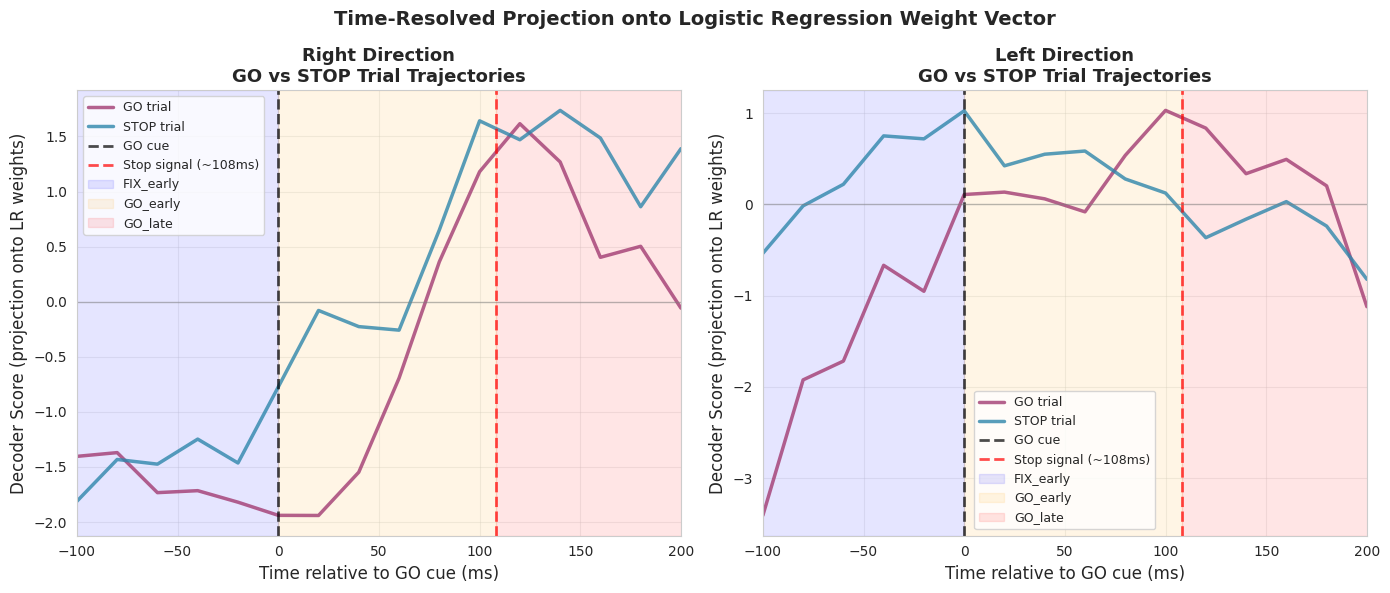

In [9]:
# Plot time-resolved projections for GO vs STOP trials
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get projection results
    go_time = projection_results[direction]['go_time']
    go_proj = projection_results[direction]['go_proj']
    stop_time = projection_results[direction]['stop_time']
    stop_proj = projection_results[direction]['stop_proj']
    
    # Get mean_ssd for this direction (from prepared_data)
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Plot GO trial
    if go_time is not None:
        ax.plot(go_time, go_proj, linewidth=2.5, label='GO trial', 
                color='#A23B72', alpha=0.8)
    
    # Plot STOP trial
    if stop_time is not None:
        ax.plot(stop_time, stop_proj, linewidth=2.5, label='STOP trial', 
                color='#2E86AB', alpha=0.8)
    
    # Add vertical lines for key events
    ax.axvline(0, color='black', linestyle='--', linewidth=2, 
               label='GO cue', alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, 
               label=f'Stop signal (~{mean_ssd:.0f}ms)', alpha=0.7)
    
    # Add horizontal line at zero
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Shade epoch regions
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.1, color='blue', label='FIX_early')
    ax.axvspan(-mean_ssd, 0, alpha=0.1, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.1, color='orange', label='GO_early')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.1, color='red', label='GO_late')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=12)
    ax.set_ylabel('Decoder Score (projection onto LR weights)', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nGO vs STOP Trial Trajectories', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle('Time-Resolved Projection onto Logistic Regression Weight Vector', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

This visualization shows how the decoder score (projection onto the LR weight vector) evolves over time for exemplar GO and STOP trials:

- **Decoder Score**: Represents the position along the FIX-GO axis learned by the logistic regression model. Higher values = more GO-like, lower values = more FIX-like.

- **Shaded Regions**: The four epochs used for decoder training (FIX_early, FIX_late, GO_early, GO_late).

- **GO Trial (pink)**: Should show a smooth transition from negative (FIX-like) to positive (GO-like) values around the go cue, leading to movement execution.

- **STOP Trial (blue)**: Critical comparison - does it maintain FIX-like state, transition partially, or fully transition to GO-like state despite stopping successfully?

- **Stop Signal Timing**: Red dashed line shows when the stop signal appears (~108ms post-go-cue). This is the critical window where inhibitory control must be exerted.

**Key Question**: Do STOP and GO trials diverge in decoder space, and if so, when?

### 9.5 Population Average: All STOP vs Matched GO Trials

In [10]:
# Compute projections for all STOP trials and matched GO trials
import numpy as np

population_projections = {}

for direction in directions:
    info = exemplar_trials[direction]
    
    # Get all STOP trials for this direction
    stop_trial_numbers = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    # Get all GO trials from test set for this direction
    test_meta = normalized_datasets[direction]['meta_test']
    go_trial_numbers = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    # Randomly select GO trials to match the number of STOP trials
    n_stop = len(stop_trial_numbers)
    if len(go_trial_numbers) >= n_stop:
        np.random.seed(42)  # For reproducibility
        selected_go_trials = np.random.choice(go_trial_numbers, size=n_stop, replace=False)
    else:
        selected_go_trials = go_trial_numbers
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  STOP trials: {n_stop}")
    print(f"  Selected GO trials: {len(selected_go_trials)}")
    
    # Compute projections for all STOP trials
    stop_projections = []
    for trial_num in stop_trial_numbers:
        time_bins, proj = compute_time_resolved_projection(
            session_data,
            trial_num,
            direction,
            info['lr_weights'],
            info['cell_ids'],
            info['train_mean'],
            info['train_std'],
            time_window=TIME_WINDOW,
            bin_size=BIN_SIZE
        )
        if proj is not None:
            stop_projections.append(proj)
    
    # Compute projections for all selected GO trials
    go_projections = []
    for trial_num in selected_go_trials:
        time_bins, proj = compute_time_resolved_projection(
            session_data,
            trial_num,
            direction,
            info['lr_weights'],
            info['cell_ids'],
            info['train_mean'],
            info['train_std'],
            time_window=TIME_WINDOW,
            bin_size=BIN_SIZE
        )
        if proj is not None:
            go_projections.append(proj)
    
    # Convert to arrays
    stop_projections = np.array(stop_projections)  # Shape: (n_trials, n_bins)
    go_projections = np.array(go_projections)      # Shape: (n_trials, n_bins)
    
    # Compute mean and SEM
    stop_mean = stop_projections.mean(axis=0)
    stop_sem = stop_projections.std(axis=0) / np.sqrt(len(stop_projections))
    
    go_mean = go_projections.mean(axis=0)
    go_sem = go_projections.std(axis=0) / np.sqrt(len(go_projections))
    
    population_projections[direction] = {
        'time_bins': time_bins,
        'stop_mean': stop_mean,
        'stop_sem': stop_sem,
        'stop_n': len(stop_projections),
        'go_mean': go_mean,
        'go_sem': go_sem,
        'go_n': len(go_projections)
    }
    
    print(f"  Successfully computed projections for {len(stop_projections)} STOP and {len(go_projections)} GO trials")

print("\n✓ Population projections computed")


Right Direction:
  STOP trials: 40
  Selected GO trials: 40


  Successfully computed projections for 40 STOP and 40 GO trials

Left Direction:
  STOP trials: 37
  Selected GO trials: 37
  Successfully computed projections for 37 STOP and 37 GO trials

✓ Population projections computed


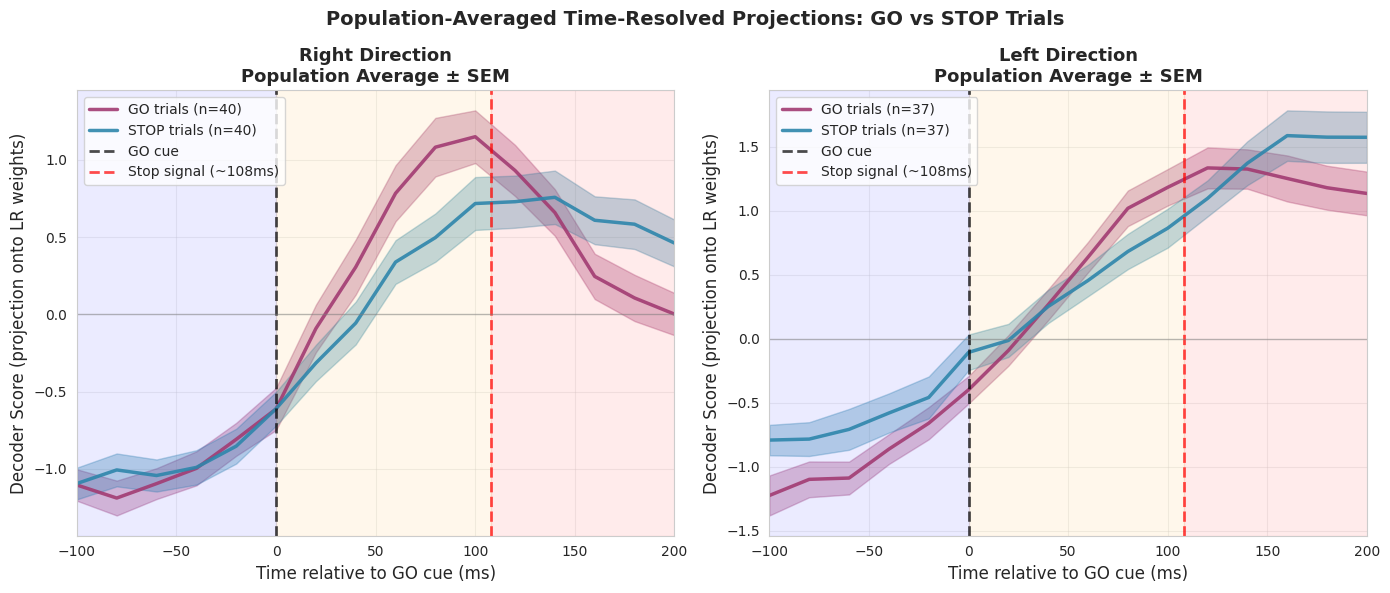

In [11]:
# Plot population average projections with SEM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    # Get population projection results
    pop_data = population_projections[direction]
    time_bins = pop_data['time_bins']
    
    stop_mean = pop_data['stop_mean']
    stop_sem = pop_data['stop_sem']
    stop_n = pop_data['stop_n']
    
    go_mean = pop_data['go_mean']
    go_sem = pop_data['go_sem']
    go_n = pop_data['go_n']
    
    # Get mean_ssd for this direction
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Plot GO trials (mean ± SEM)
    ax.plot(time_bins, go_mean, linewidth=2.5, label=f'GO trials (n={go_n})', 
            color='#A23B72', alpha=0.9)
    ax.fill_between(time_bins, go_mean - go_sem, go_mean + go_sem, 
                     color='#A23B72', alpha=0.3)
    
    # Plot STOP trials (mean ± SEM)
    ax.plot(time_bins, stop_mean, linewidth=2.5, label=f'STOP trials (n={stop_n})', 
            color='#2E86AB', alpha=0.9)
    ax.fill_between(time_bins, stop_mean - stop_sem, stop_mean + stop_sem, 
                     color='#2E86AB', alpha=0.3)
    
    # Add vertical lines for key events
    ax.axvline(0, color='black', linestyle='--', linewidth=2, 
               label='GO cue', alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, 
               label=f'Stop signal (~{mean_ssd:.0f}ms)', alpha=0.7)
    
    # Add horizontal line at zero
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Shade epoch regions
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=12)
    ax.set_ylabel('Decoder Score (projection onto LR weights)', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction\nPopulation Average ± SEM', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle('Population-Averaged Time-Resolved Projections: GO vs STOP Trials', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation: Population Average

This analysis averages across **all available trials** rather than single exemplars:

**Key Features:**
- **GO trials**: Randomly selected to match the number of STOP trials (balanced comparison)
- **Shaded error bands**: ± 1 SEM (standard error of the mean) showing trial-to-trial variability
- **Sample size**: Shown in legend (typically ~11-13 STOP trials, matched GO trials)

**What to look for:**
1. **Pre-go-cue period** (before t=0): Do both trial types start at similar FIX-like states?
2. **GO-early period** (0-108ms): Do trajectories begin to diverge?
3. **Post-signal period** (after 108ms): 
   - GO trials should continue rising (movement execution)
   - STOP trials should... maintain FIX? Plateau? Continue rising?
4. **Error bands**: Overlapping bands suggest no reliable difference; separated bands indicate divergence

**Critical question**: At what time point (if any) do the STOP and GO trajectories reliably diverge in this FIX-GO decoder space?

### 9.6 Bootstrap Analysis: Robust Population Estimates

Perform bootstrap resampling to obtain robust estimates of population trajectories and variability.

In [20]:
# Bootstrap analysis parameters
N_BOOTSTRAP = 1000
N_SAMPLES_PER_CONDITION = 30

bootstrap_results = {}

for direction in directions:
    info = exemplar_trials[direction]
    
    # Get all available trial numbers
    stop_trial_numbers = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    test_meta = normalized_datasets[direction]['meta_test']
    go_trial_numbers = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Available STOP trials: {len(stop_trial_numbers)}")
    print(f"  Available GO trials: {len(go_trial_numbers)}")
    print(f"  Bootstrap iterations: {N_BOOTSTRAP}")
    print(f"  Samples per iteration: {N_SAMPLES_PER_CONDITION} STOP + {N_SAMPLES_PER_CONDITION} GO")
    
    # Pre-compute projections for all trials to speed up bootstrap
    print("  Pre-computing projections for all trials...")
    
    stop_all_projections = {}
    for trial_num in stop_trial_numbers:
        time_bins, proj = compute_time_resolved_projection(
            session_data,
            trial_num,
            direction,
            info['lr_weights'],
            info['cell_ids'],
            info['train_mean'],
            info['train_std'],
            time_window=TIME_WINDOW,
            bin_size=BIN_SIZE
        )
        if proj is not None:
            stop_all_projections[trial_num] = proj
    
    go_all_projections = {}
    for trial_num in go_trial_numbers:
        time_bins, proj = compute_time_resolved_projection(
            session_data,
            trial_num,
            direction,
            info['lr_weights'],
            info['cell_ids'],
            info['train_mean'],
            info['train_std'],
            time_window=TIME_WINDOW,
            bin_size=BIN_SIZE
        )
        if proj is not None:
            go_all_projections[trial_num] = proj
    
    # Get valid trial numbers (those with projections)
    valid_stop_trials = list(stop_all_projections.keys())
    valid_go_trials = list(go_all_projections.keys())
    
    print(f"  Valid STOP trials: {len(valid_stop_trials)}")
    print(f"  Valid GO trials: {len(valid_go_trials)}")
    
    # Bootstrap iterations
    print("  Running bootstrap iterations...")
    
    stop_means = []
    stop_stds = []
    go_means = []
    go_stds = []
    
    np.random.seed(42)  # For reproducibility
    
    for iteration in range(N_BOOTSTRAP):
        # Randomly sample trials
        sampled_stop = np.random.choice(valid_stop_trials, size=N_SAMPLES_PER_CONDITION, replace=True)
        sampled_go = np.random.choice(valid_go_trials, size=N_SAMPLES_PER_CONDITION, replace=True)
        
        # Get projections for sampled trials
        stop_sample_projs = np.array([stop_all_projections[t] for t in sampled_stop])
        go_sample_projs = np.array([go_all_projections[t] for t in sampled_go])
        
        # Calculate mean and std for this bootstrap sample
        stop_means.append(stop_sample_projs.mean(axis=0))
        stop_stds.append(stop_sample_projs.std(axis=0))
        
        go_means.append(go_sample_projs.mean(axis=0))
        go_stds.append(go_sample_projs.std(axis=0))
        
        if (iteration + 1) % 200 == 0:
            print(f"    Completed {iteration + 1}/{N_BOOTSTRAP} iterations")
    
    # Convert to arrays
    stop_means = np.array(stop_means)  # Shape: (n_bootstrap, n_bins)
    stop_stds = np.array(stop_stds)    # Shape: (n_bootstrap, n_bins)
    go_means = np.array(go_means)      # Shape: (n_bootstrap, n_bins)
    go_stds = np.array(go_stds)        # Shape: (n_bootstrap, n_bins)
    
    # Calculate mean and std across bootstrap iterations
    bootstrap_results[direction] = {
        'time_bins': time_bins,
        'stop_mean_of_means': stop_means.mean(axis=0),
        'stop_mean_of_stds': stop_stds.mean(axis=0),
        'stop_std_of_means': stop_means.std(axis=0),
        'go_mean_of_means': go_means.mean(axis=0),
        'go_mean_of_stds': go_stds.mean(axis=0),
        'go_std_of_means': go_means.std(axis=0),
    }
    
    print(f"  ✓ Bootstrap complete!")

print("\n✓ Bootstrap analysis complete for both directions")


Right Direction:
  Available STOP trials: 40
  Available GO trials: 87
  Bootstrap iterations: 1000
  Samples per iteration: 30 STOP + 30 GO
  Pre-computing projections for all trials...
  Valid STOP trials: 40
  Valid GO trials: 87
  Running bootstrap iterations...
    Completed 200/1000 iterations
    Completed 400/1000 iterations
    Completed 600/1000 iterations
    Completed 800/1000 iterations
    Completed 1000/1000 iterations
  ✓ Bootstrap complete!

Left Direction:
  Available STOP trials: 37
  Available GO trials: 90
  Bootstrap iterations: 1000
  Samples per iteration: 30 STOP + 30 GO
  Pre-computing projections for all trials...
  Valid STOP trials: 37
  Valid GO trials: 90
  Running bootstrap iterations...
    Completed 200/1000 iterations
    Completed 400/1000 iterations
    Completed 600/1000 iterations
    Completed 800/1000 iterations
    Completed 1000/1000 iterations
  ✓ Bootstrap complete!

✓ Bootstrap analysis complete for both directions


(-100, 200)
(-100, 200)


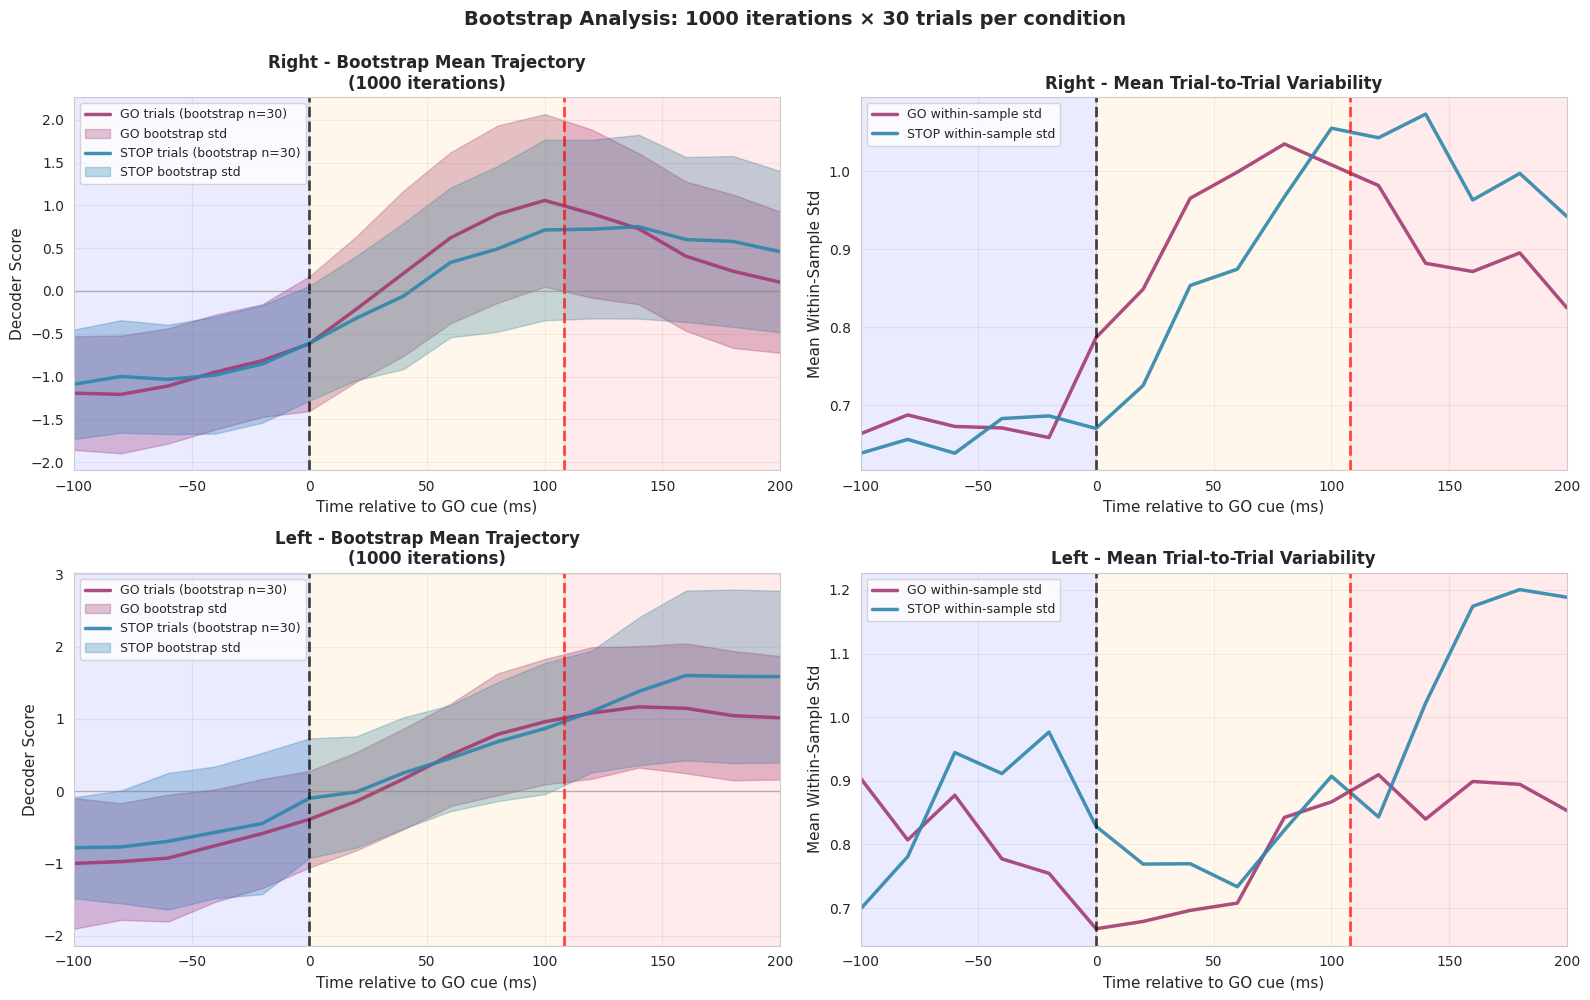

In [21]:
# Plot bootstrap results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, direction in enumerate(directions):
    # Get bootstrap results
    boot_data = bootstrap_results[direction]
    time_bins = boot_data['time_bins']
    
    stop_mean = boot_data['stop_mean_of_means']
    stop_std_of_means = boot_data['stop_std_of_means'] #/ np.sqrt(N_BOOTSTRAP)
    stop_mean_std = boot_data['stop_mean_of_stds'] #/ np.sqrt(N_BOOTSTRAP)

    go_mean = boot_data['go_mean_of_means']
    go_std_of_means = boot_data['go_std_of_means'] #/ np.sqrt(N_BOOTSTRAP)
    go_mean_std = boot_data['go_mean_of_stds'] #/ np.sqrt(N_BOOTSTRAP)
    
    # Get mean_ssd for this direction
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Top plot: Mean trajectory with bootstrap confidence
    ax = axes[idx, 0]
    
    # Plot mean trajectories with bootstrap std (uncertainty in the mean)
    ax.plot(time_bins, go_mean, linewidth=2.5, 
            label=f'GO trials (bootstrap n={N_SAMPLES_PER_CONDITION})', 
            color='#A23B72', alpha=0.9)
    #ax.fill_between(time_bins, go_mean - go_std_of_means, go_mean + go_std_of_means, 
    ax.fill_between(time_bins, go_mean - go_mean_std, go_mean + go_mean_std, 
                     color='#A23B72', alpha=0.3, label='GO bootstrap std')
    
    ax.plot(time_bins, stop_mean, linewidth=2.5, 
            label=f'STOP trials (bootstrap n={N_SAMPLES_PER_CONDITION})', 
            color='#2E86AB', alpha=0.9)
    #ax.fill_between(time_bins, stop_mean - stop_std_of_means, stop_mean + stop_std_of_means, 
    ax.fill_between(time_bins, stop_mean - stop_mean_std, stop_mean + stop_mean_std, 
                     color='#2E86AB', alpha=0.3, label='STOP bootstrap std')
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Decoder Score', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Bootstrap Mean Trajectory\n({N_BOOTSTRAP} iterations)', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)
    print(TIME_WINDOW)
    
    # Bottom plot: Mean within-sample variability (mean of stds)
    ax = axes[idx, 1]
    
    ax.plot(time_bins, go_mean_std, linewidth=2.5, 
            label=f'GO within-sample std', 
            color='#A23B72', alpha=0.9)
    
    ax.plot(time_bins, stop_mean_std, linewidth=2.5, 
            label=f'STOP within-sample std', 
            color='#2E86AB', alpha=0.9)
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Mean Within-Sample Std', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Mean Trial-to-Trial Variability', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle(f'Bootstrap Analysis: {N_BOOTSTRAP} iterations × {N_SAMPLES_PER_CONDITION} trials per condition', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Interpretation: Bootstrap Analysis

**Bootstrap Method:**
- **1000 iterations** of randomly sampling 5 STOP + 5 GO trials
- Sampling with replacement to estimate sampling variability
- Pre-computed all projections for speed

**Top Row - Mean Trajectories:**
- **Solid lines**: Mean of means across 1000 bootstrap iterations
- **Shaded bands**: ±1 SD of the bootstrap distribution (variability across different samples)
- Shows the expected trajectory when analyzing 5 trials per condition
- Narrow bands = stable estimate; wide bands = high sampling variability

**Bottom Row - Within-Sample Variability:**
- Shows the average **trial-to-trial variability** (mean STD across bootstrap iterations)
- Quantifies how much individual trials differ from each other
- High variability = heterogeneous trial responses; low variability = consistent responses

**Key Comparisons:**
1. **Trajectory separation**: Do GO and STOP bands overlap or diverge?
2. **Temporal dynamics**: When does divergence occur (if at all)?
3. **Variability patterns**: Does one condition show more trial-to-trial variability than the other?

**Statistical Note**: Bootstrap provides a robust, distribution-free estimate of the population mean and its uncertainty without assuming normality.

---

## 10. Statistical Test: GO-STOP vs GO-GO Differences

Test whether the difference between GO and STOP trials is larger than natural trial-to-trial variability (GO vs GO).

In [22]:
# Statistical test: GO-STOP vs GO-GO differences
N_ITERATIONS = 1000 
# TIME_WINDOW = [50, 300]

statistical_test_results = {}

for direction in directions:
    info = exemplar_trials[direction]
    
    # Get all available trial projections (reuse from bootstrap if available)
    stop_trial_numbers = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_num)
    ]['trial_number'].unique()
    
    test_meta = normalized_datasets[direction]['meta_test']
    go_trial_numbers = test_meta[test_meta['label'] == 1]['trial_number'].unique()
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Available STOP trials: {len(stop_trial_numbers)}")
    print(f"  Available GO trials: {len(go_trial_numbers)}")
    print(f"  Running {N_ITERATIONS} iterations...")
    
    # Pre-compute all projections
    stop_projections = {}
    for trial_num in stop_trial_numbers:
        time_bins, proj = compute_time_resolved_projection(
            session_data, trial_num, direction,
            info['lr_weights'], info['cell_ids'],
            info['train_mean'], info['train_std'],
            time_window=TIME_WINDOW, bin_size=BIN_SIZE
        )
        if proj is not None:
            stop_projections[trial_num] = proj
    
    go_projections = {}
    for trial_num in go_trial_numbers:
        time_bins, proj = compute_time_resolved_projection(
            session_data, trial_num, direction,
            info['lr_weights'], info['cell_ids'],
            info['train_mean'], info['train_std'],
            time_window=TIME_WINDOW, bin_size=BIN_SIZE
        )
        if proj is not None:
            go_projections[trial_num] = proj
    
    valid_stop = list(stop_projections.keys())
    valid_go = list(go_projections.keys())
    
    print(f"  Valid STOP trials: {len(valid_stop)}")
    print(f"  Valid GO trials: {len(valid_go)}")
    
    # Storage for differences
    go_stop_diffs = []  # Absolute differences between GO and STOP
    go_go_diffs = []    # Absolute differences between GO and GO (baseline variability)
    
    np.random.seed(42)
    
    for iteration in range(N_ITERATIONS):
        # Randomly sample 3 distinct GO trials and 1 STOP trial
        if len(valid_go) >= 3:
            sampled_go = np.random.choice(valid_go, size=3, replace=False)
            go_trial_1, go_trial_2, go_trial_3 = sampled_go
        else:
            # If we don't have 3 GO trials, sample with replacement
            sampled_go = np.random.choice(valid_go, size=3, replace=False)
            go_trial_1, go_trial_2, go_trial_3 = sampled_go
        
        stop_trial = np.random.choice(valid_stop)
        
        # Compute absolute differences
        # GO-STOP: compare go_trial_1 with stop_trial
        go_stop_diff = np.abs(go_projections[go_trial_1] - stop_projections[stop_trial])
        
        # GO-GO: compare go_trial_2 with go_trial_3
        go_go_diff = np.abs(go_projections[go_trial_2] - go_projections[go_trial_3])
        
        go_stop_diffs.append(go_stop_diff)
        go_go_diffs.append(go_go_diff)
        
        if (iteration + 1) % 200 == 0:
            print(f"    Completed {iteration + 1}/{N_ITERATIONS} iterations")
    
    # Convert to arrays
    go_stop_diffs = np.array(go_stop_diffs)  # Shape: (n_iterations, n_bins)
    go_go_diffs = np.array(go_go_diffs)      # Shape: (n_iterations, n_bins)
    
    # Compute statistics
    go_stop_mean = go_stop_diffs.mean(axis=0)
    go_stop_std = go_stop_diffs.std(axis=0)
    
    go_go_mean = go_go_diffs.mean(axis=0)
    go_go_std = go_go_diffs.std(axis=0)
    
    # Test at each time bin: is GO-STOP > GO-GO?
    # Simple comparison: proportion of iterations where GO-STOP > GO-GO
    proportion_greater = (go_stop_diffs > go_go_diffs).mean(axis=0)
    
    statistical_test_results[direction] = {
        'time_bins': time_bins,
        'go_stop_mean': go_stop_mean,
        'go_stop_std': go_stop_std,
        'go_go_mean': go_go_mean,
        'go_go_std': go_go_std,
        'proportion_greater': proportion_greater,
        'go_stop_diffs': go_stop_diffs,
        'go_go_diffs': go_go_diffs
    }
    
    print(f"  ✓ Statistical test complete!")

print("\n✓ Statistical test complete for both directions")


Right Direction:
  Available STOP trials: 40
  Available GO trials: 87
  Running 1000 iterations...
  Valid STOP trials: 40
  Valid GO trials: 87
    Completed 200/1000 iterations
    Completed 400/1000 iterations
    Completed 600/1000 iterations
    Completed 800/1000 iterations
    Completed 1000/1000 iterations
  ✓ Statistical test complete!

Left Direction:
  Available STOP trials: 37
  Available GO trials: 90
  Running 1000 iterations...
  Valid STOP trials: 37
  Valid GO trials: 90
    Completed 200/1000 iterations
    Completed 400/1000 iterations
    Completed 600/1000 iterations
    Completed 800/1000 iterations
    Completed 1000/1000 iterations
  ✓ Statistical test complete!

✓ Statistical test complete for both directions


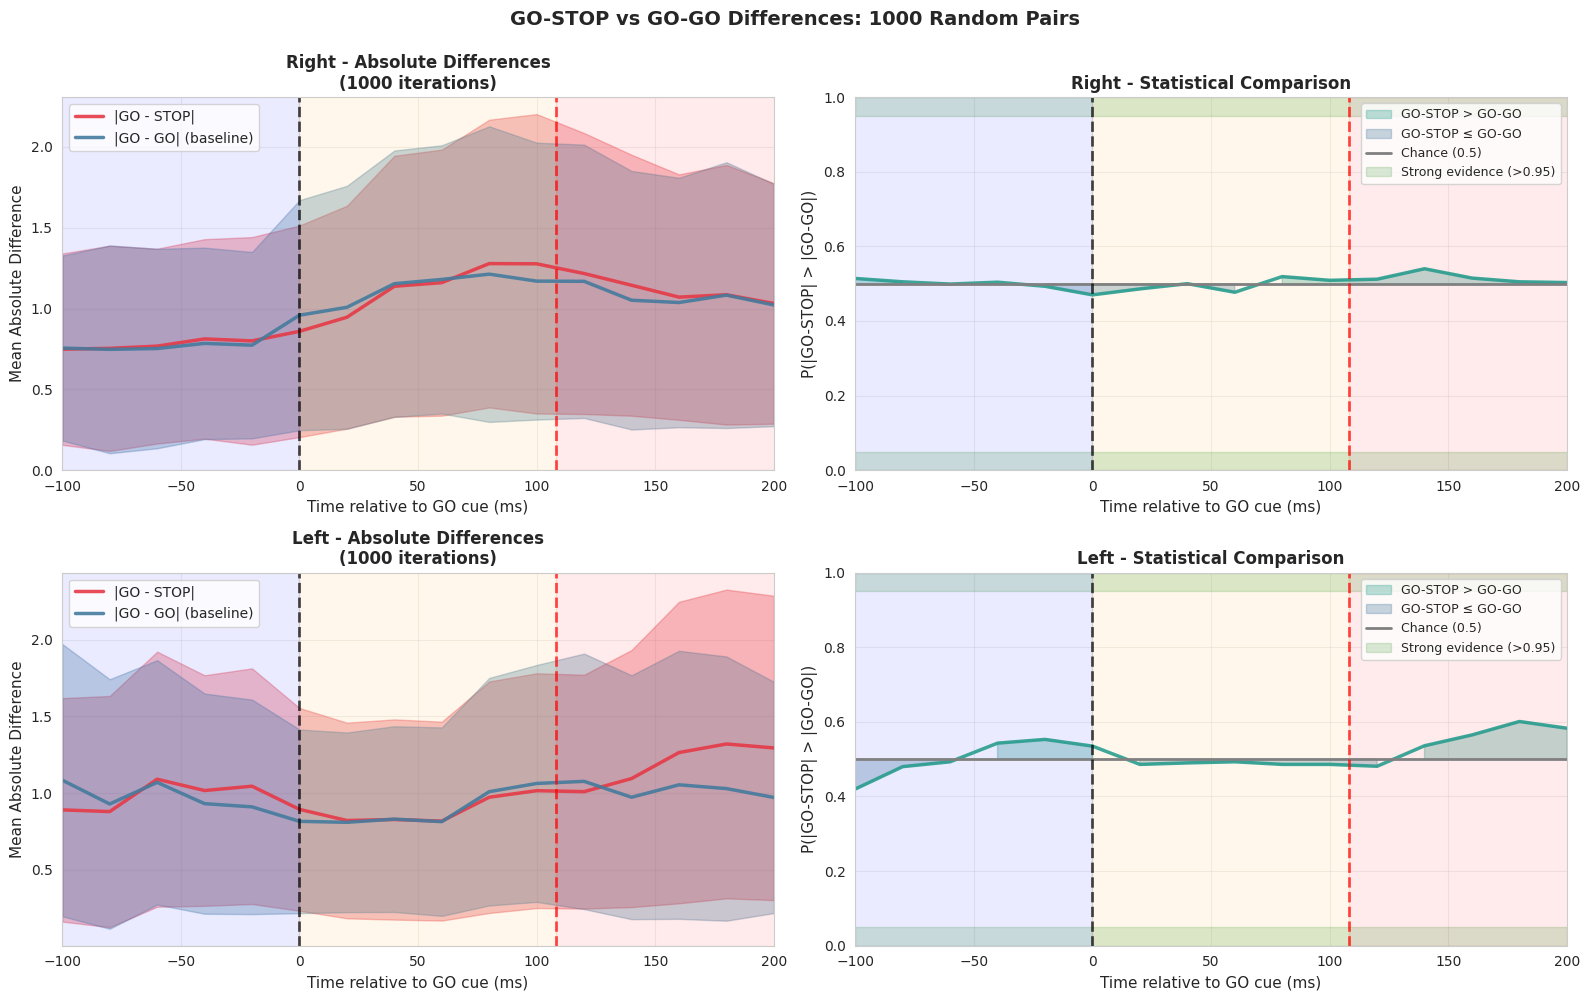

In [23]:
# Plot statistical test results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, direction in enumerate(directions):
    results = statistical_test_results[direction]
    time_bins = results['time_bins']
    
    go_stop_mean = results['go_stop_mean']
    go_stop_std = results['go_stop_std']
    
    go_go_mean = results['go_go_mean']
    go_go_std = results['go_go_std']
    
    proportion_greater = results['proportion_greater']
    
    mean_ssd = prepared_data['datasets'][direction]['mean_ssd']
    
    # Top plot: Mean absolute differences
    ax = axes[idx, 0]
    
    ax.plot(time_bins, go_stop_mean, linewidth=2.5, 
            label='|GO - STOP|', color='#E63946', alpha=0.9)
    ax.fill_between(time_bins, go_stop_mean - go_stop_std, go_stop_mean + go_stop_std,
                     color='#E63946', alpha=0.3)
    
    ax.plot(time_bins, go_go_mean, linewidth=2.5, 
            label='|GO - GO| (baseline)', color='#457B9D', alpha=0.9)
    ax.fill_between(time_bins, go_go_mean - go_go_std, go_go_mean + go_go_std,
                     color='#457B9D', alpha=0.3)
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('Mean Absolute Difference', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Absolute Differences\n({N_ITERATIONS} iterations)', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)
    
    # Bottom plot: Proportion where GO-STOP > GO-GO
    ax = axes[idx, 1]
    
    ax.plot(time_bins, proportion_greater, linewidth=2.5, 
            color='#2A9D8F', alpha=0.9)
    ax.fill_between(time_bins, proportion_greater, 0.5, 
                     where=(proportion_greater > 0.5),
                     color='#2A9D8F', alpha=0.3, 
                     label='GO-STOP > GO-GO')
    ax.fill_between(time_bins, proportion_greater, 0.5, 
                     where=(proportion_greater <= 0.5),
                     color='#457B9D', alpha=0.3, 
                     label='GO-STOP ≤ GO-GO')
    
    # Add reference line at 0.5 (chance)
    ax.axhline(0.5, color='gray', linestyle='-', linewidth=2, label='Chance (0.5)')
    
    # Shade significance regions (e.g., > 0.95 or < 0.05)
    ax.axhspan(0.95, 1.0, alpha=0.15, color='green', label='Strong evidence (>0.95)')
    ax.axhspan(0.0, 0.05, alpha=0.15, color='green')
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    # Shade epochs
    ax.axvspan(-2*mean_ssd, -mean_ssd, alpha=0.08, color='blue')
    ax.axvspan(-mean_ssd, 0, alpha=0.08, color='blue')
    ax.axvspan(0, mean_ssd, alpha=0.08, color='orange')
    ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.08, color='red')
    
    ax.set_xlabel('Time relative to GO cue (ms)', fontsize=11)
    ax.set_ylabel('P(|GO-STOP| > |GO-GO|)', fontsize=11)
    ax.set_title(f'{dir_map[direction]} - Statistical Comparison', 
                 fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(TIME_WINDOW)

plt.suptitle(f'GO-STOP vs GO-GO Differences: {N_ITERATIONS} Random Pairs', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Interpretation: Statistical Test

**Methodology:**
- **1000 iterations** of randomly sampling trials
- Each iteration samples **3 distinct GO trials** + **1 STOP trial**:
  - **GO-STOP comparison**: |GO₁ - STOP|
  - **GO-GO comparison**: |GO₂ - GO₃| (baseline variability)
- Independent samples ensure unbiased comparison

**Top Row - Absolute Differences:**
- **Red**: Mean |GO - STOP| difference across iterations
- **Blue**: Mean |GO - GO| difference (baseline trial-to-trial variability)
- **Shaded bands**: ±1 SD across iterations
- If red > blue: GO-STOP differences exceed baseline variability

**Bottom Row - Statistical Comparison:**
- **Y-axis**: Proportion of iterations where |GO-STOP| > |GO-GO|
- **0.5** (gray line): Chance level (no difference)
- **> 0.95** (green): Strong evidence that GO-STOP > baseline
- **< 0.05** (green): Strong evidence that GO-STOP < baseline (unlikely)

**Key Questions:**
1. **Are GO-STOP differences real or just noise?**
   - If proportion consistently > 0.95: Real difference
   - If proportion ≈ 0.5: No systematic difference (just variability)

2. **When do differences emerge?**
   - Look for time periods where proportion > 0.95
   - Pre-go-cue: Should be ≈ 0.5 (trials haven't diverged yet)
   - Post-signal: If > 0.95, stopping mechanisms are detectable in this axis

**Critical Test**: This directly addresses whether the FIX-GO decoder axis captures stopping-related variance or just trial-to-trial noise.